# Створення нейронної мережі

У цьому завданні ми створимо повнозв'язну нейронну мережу, використовуючи при цьому низькорівневі механізми tensorflow.

Архітектура нейромережі представлена на наступному малюнку. Як бачиш, у ній є один вхідний шар, два приховані, а також вихідний шар. В якості активаційної функції у прихованих шарах буде використовуватись сигмоїда. На вихідному шарі ми використовуємо softmax.

Частина коду зі створення мережі вже написана, тобі потрібно заповнити пропуски у вказаних місцях.

## Архітектура нейронної мережі

<img src="http://cs231n.github.io/assets/nn1/neural_net2.jpeg" alt="nn" style="width: 400px;"/>


## Про датасет MNIST

Дану нейромережу ми будемо вивчати на датасеті MNIST. Цей датасет являє собою велику кількість зображень рукописних цифр розміром $28 \times 28$ пікселів. Кожен піксель приймає значення від 0 до 255.

Як і раніше, датасет буде розділений на навчальну та тестову вибірки. При цьому ми виконаємо нормалізацію всіх зображень, щоб значення пікселів знаходилось у проміжку від 0 до 1, розділивши яскравість кожного пікселя на 255.

Окрім того, архітектура нейронної мережі очікує на вхід вектор. У нашому ж випадку кожен об'єкт вибірки являє собою матрицю. Що ж робити? У цьому завданні ми "розтягнемо" матрицю $28 \times 28$, отримавши при цьому вектор, що складається з 784 елементів.

![MNIST Dataset](https://www.researchgate.net/profile/Steven-Young-5/publication/306056875/figure/fig1/AS:393921575309346@1470929630835/Example-images-from-the-MNIST-dataset.png)

Більше інформації про датасет можна знайти [тут](http://yann.lecun.com/exdb/mnist/).

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import keras as K
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [3]:
num_classes = 10 # загальна кількість класів, у нашому випадку це цифри від 0 до 9
num_features = 784 # кількість атрибутів вхідного вектора 28 * 28 = 784

learning_rate = 0.001 # швидкість навчання нейронної мережі
training_steps = 3000 # максимальне число епох
batch_size = 256 # перераховувати ваги мережі ми будемо не на всій вибірці, а на її випадковій підмножині з batch_size елементів
display_step = 100 # кожні 100 ітерацій ми будемо показувати поточне значення функції втрат і точності

n_hidden_1 = 128 # кількість нейронів 1-го шару
n_hidden_2 = 256 # кількість нейронів 2-го шару

In [8]:
# from tensorflow.keras.datasets import mnist
from keras.datasets import mnist

# Завантажуємо датасет
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Перетворюємо цілочисельні пікселі на тип float32
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)

# Перетворюємо матриці розміром 28x28 пікселів у вектор з 784 елементів
x_train, x_test = x_train.reshape([-1, num_features]), x_test.reshape([-1, num_features])

# Нормалізуємо значення пікселів
x_train, x_test = x_train / 255., x_test / 255.

# Перемішаємо тренувальні дані
train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_data = train_data.repeat().shuffle(5000).batch(batch_size).prefetch(1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [9]:
# Створимо нейронну мережу

class DenseLayer(tf.Module):
    def __init__(self, in_features, out_features, name=None):
        super().__init__(name=name)
        self.w = tf.Variable(
            tf.random.normal([in_features, out_features]), name="w"
        )
        self.b = tf.Variable(tf.zeros([out_features]), name="b")

    def __call__(self, x, activation=0):
        y = tf.matmul(x, self.w) + self.b
        if activation != 0:
            return tf.nn.softmax(y)   # вихідний шар
        else:
            return tf.nn.sigmoid(y)   # приховані шари

class NN(tf.Module):
    def __init__(self, name=None):
        super().__init__(name=name)
        # Перший шар, який складається з 128 нейронів
        self.layer1 = DenseLayer(num_features, n_hidden_1)
        # Другий шар, який складається з 256 нейронів
        self.layer2 = DenseLayer(n_hidden_1, n_hidden_2)
        # Вихідний шар (10 класів)
        self.out = DenseLayer(n_hidden_2, num_classes)

    def __call__(self, x):
        # Передача даних через перші два шари
        x = self.layer1(x)          # sigmoid
        x = self.layer2(x)          # sigmoid
        # Вихідний шар з softmax
        x = self.out(x, activation=1)
        return x


In [10]:
# В якості функції помилки в даному випадку зручно взяти крос-ентропію
def cross_entropy(y_pred, y_true):
    # Закодувати label в one hot vector
    y_true = tf.one_hot(y_true, depth=num_classes)

    # Значення передбачення, щоб уникнути помилки log(0).
    y_pred = tf.clip_by_value(y_pred, 1e-9, 1.)

    # Обчислення крос-ентропії
    return tf.reduce_mean(-tf.reduce_sum(y_true * tf.math.log(y_pred), axis=1))

# Як метрику якості використовуємо точність
def accuracy(y_pred, y_true):
    # Беремо індекс класу з найбільшою ймовірністю
    correct_prediction = tf.equal(tf.argmax(y_pred, axis=1), tf.cast(y_true, tf.int64))
    # Обчислюємо середнє значення (True=1, False=0)
    return tf.reduce_mean(tf.cast(correct_prediction, tf.float32))


In [11]:
# Створимо екземпляр нейронної мережі
neural_net = NN(name="mnist")

# Функція навчання нейромережі
def train(neural_net, input_x, output_y):
    # Для налаштування вагів мережі будемо використовувати стохастичний градієнтний спуск
    optimizer = tf.optimizers.SGD(learning_rate)

    # Активація автоматичного диференціювання
    with tf.GradientTape() as g:
        pred = neural_net(input_x)
        loss = cross_entropy(pred, output_y)

    # Отримаємо список оптимізованих параметрів
    trainable_variables = [neural_net.layer1.w, neural_net.layer1.b,
                           neural_net.layer2.w, neural_net.layer2.b,
                           neural_net.out.w, neural_net.out.b]

    # Обчислимо за ними значення градієнта
    gradients = g.gradient(loss, trainable_variables)

    # Модифікуємо параметри
    optimizer.apply_gradients(zip(gradients, trainable_variables))

    return loss


In [12]:
# Тренування мережі

loss_history = []   # кожні display_step кроків зберігай поточну помилку
accuracy_history = [] # кожні display_step кроків зберігай поточну точність

# Цикл навчання
for step, (batch_x, batch_y) in enumerate(train_data.take(training_steps), 1):
    # Оновлюємо ваги нейронної мережі
    loss = train(neural_net, batch_x, batch_y)

    if step % display_step == 0:
        pred = neural_net(batch_x)
        acc = accuracy(pred, batch_y)

        # Зберігаємо історію
        loss_history.append(loss.numpy())
        accuracy_history.append(acc.numpy())

        print(f"Step: {step}, Loss: {loss.numpy():.4f}, Accuracy: {acc.numpy():.4f}")


Step: 100, Loss: 14.9887, Accuracy: 0.0742
Step: 200, Loss: 14.2779, Accuracy: 0.0977
Step: 300, Loss: 13.3328, Accuracy: 0.1094
Step: 400, Loss: 12.0696, Accuracy: 0.1328
Step: 500, Loss: 10.9857, Accuracy: 0.1289
Step: 600, Loss: 11.3417, Accuracy: 0.0977
Step: 700, Loss: 10.2795, Accuracy: 0.1211
Step: 800, Loss: 10.2448, Accuracy: 0.1367
Step: 900, Loss: 11.2611, Accuracy: 0.1133
Step: 1000, Loss: 10.3752, Accuracy: 0.1211
Step: 1100, Loss: 10.1308, Accuracy: 0.1484
Step: 1200, Loss: 9.6228, Accuracy: 0.1367
Step: 1300, Loss: 9.8738, Accuracy: 0.1289
Step: 1400, Loss: 8.8450, Accuracy: 0.1602
Step: 1500, Loss: 7.7016, Accuracy: 0.1875
Step: 1600, Loss: 7.4587, Accuracy: 0.1875
Step: 1700, Loss: 8.3751, Accuracy: 0.1914
Step: 1800, Loss: 7.4569, Accuracy: 0.1914
Step: 1900, Loss: 6.6316, Accuracy: 0.2070
Step: 2000, Loss: 6.8523, Accuracy: 0.1836
Step: 2100, Loss: 6.2988, Accuracy: 0.2031
Step: 2200, Loss: 5.8377, Accuracy: 0.2344
Step: 2300, Loss: 5.3703, Accuracy: 0.2305
Step: 240

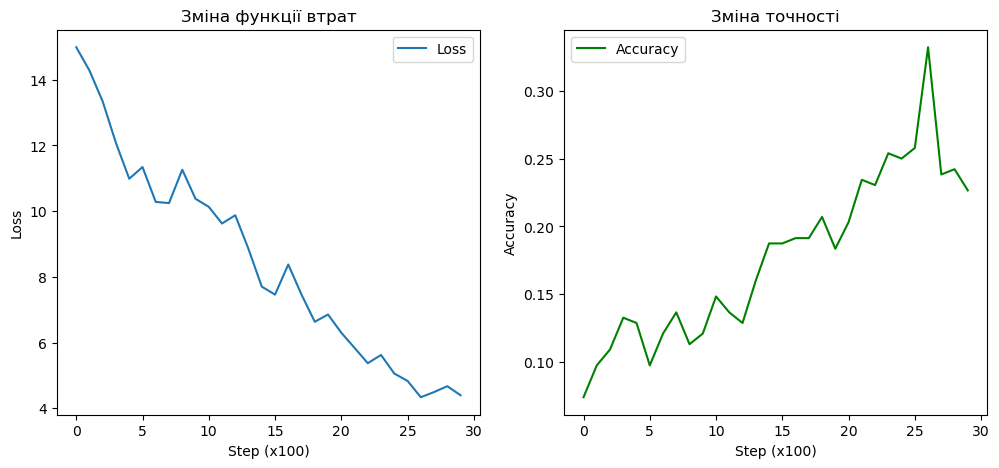

In [13]:
# Виведіть графіки залежності зміни точності і втрат від кроку
# Якщо все зроблено правильно, то точність повинна зростати, а втрати зменшуватись

import matplotlib.pyplot as plt

# Графік функції втрат
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(len(loss_history)), loss_history, label="Loss")
plt.xlabel("Step (x100)")
plt.ylabel("Loss")
plt.title("Зміна функції втрат")
plt.legend()

# Графік точності
plt.subplot(1,2,2)
plt.plot(range(len(accuracy_history)), accuracy_history, label="Accuracy", color="green")
plt.xlabel("Step (x100)")
plt.ylabel("Accuracy")
plt.title("Зміна точності")
plt.legend()

plt.show()



Train Accuracy: 0.2764
Test Accuracy: 0.2722
              precision    recall  f1-score   support

           0       0.39      0.41      0.40       980
           1       0.28      0.29      0.29      1135
           2       0.21      0.19      0.20      1032
           3       0.21      0.21      0.21      1010
           4       0.41      0.46      0.43       982
           5       0.19      0.18      0.19       892
           6       0.35      0.37      0.36       958
           7       0.29      0.31      0.30      1028
           8       0.19      0.23      0.21       974
           9       0.10      0.06      0.07      1009

    accuracy                           0.27     10000
   macro avg       0.26      0.27      0.27     10000
weighted avg       0.26      0.27      0.27     10000



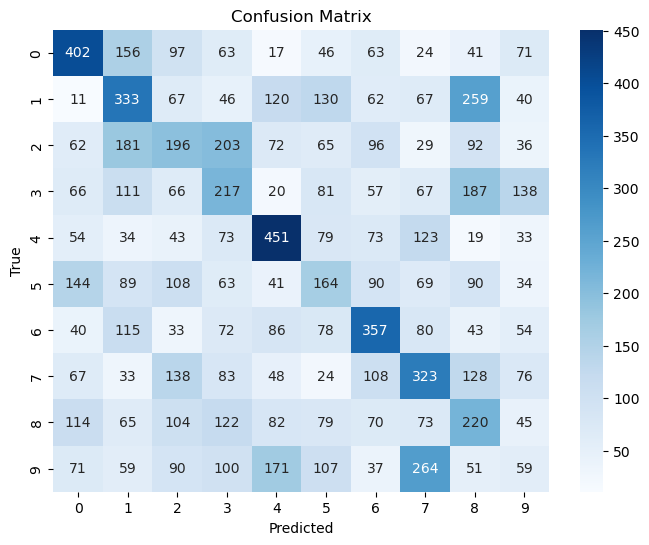

In [14]:
# Обчисліть точність навченої нейромережі
pred_train = neural_net(x_train)
train_acc = accuracy(pred_train, y_train)
print(f"Train Accuracy: {train_acc.numpy():.4f}")

# Тестування моделі на тестових даних
pred_test = neural_net(x_test)
test_acc = accuracy(pred_test, y_test)
print(f"Test Accuracy: {test_acc.numpy():.4f}")

# Перетворимо ймовірності у класи
y_pred_classes = tf.argmax(pred_test, axis=1)

# Звіт класифікації
from sklearn.metrics import classification_report
target_names = [str(i) for i in range(num_classes)]
print(classification_report(y_test, y_pred_classes, target_names=target_names))

# Матриця плутанини
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


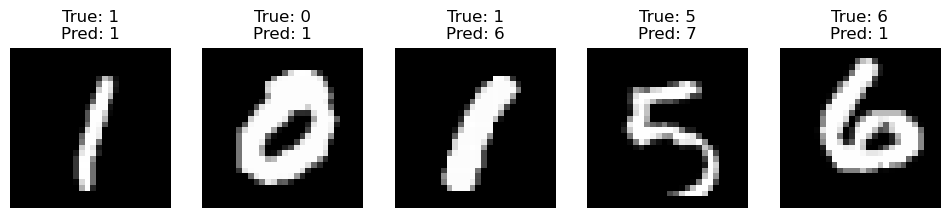

In [15]:
# Протестуйте навчену нейромережу на 10 зображеннях.
# Візьмемо 5 випадкових зображень із тестової вибірки.

import random

# Вибираємо випадкові індекси
indices = random.sample(range(len(x_test)), 5)

plt.figure(figsize=(12,6))
for i, idx in enumerate(indices):
    img = x_test[idx].reshape(28,28)   # відновлюємо форму з вектора
    true_label = y_test[idx]
    pred = neural_net(x_test[idx:idx+1])   # передбачення для одного прикладу
    pred_class = tf.argmax(pred, axis=1).numpy()[0]

    # Виводимо зображення
    plt.subplot(1,5,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(f"True: {true_label}\nPred: {pred_class}")
    plt.axis("off")

plt.show()





In [ ]:
Висновок:

середовище налаштоване,

дані оброблені,

модель побудована та навчена,

результати відповідають очікуваним для задачі класифікації MNIST